# TD3 : Régression Logistique

## ARSENA Claire

### Exercice 0 - Implémentation de la régression logistique sur Iris

In [3]:
#1. Import des bibliothèques nécessaires : 
import numpy as np
import matplotlib.pyplot as plt
#import sklearn as sk
#2. Import dataset de sklearn
from sklearn import datasets#

#3. Charger les données
iris = datasets.load_iris()

# 4. Affichage des données
print("Noms des features :", iris.feature_names)
print("\n Noms des classes cibles :", iris.target_names)
print("\n Aperçu des 5 premières lignes de données :\n", iris.data[:5])

Noms des features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 Noms des classes cibles : ['setosa' 'versicolor' 'virginica']

 Aperçu des 5 premières lignes de données :
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


### Exercice 1 - Adaptation de la base de données Iris

In [9]:
# 1. Récupération des deux premieres colonnes en X
X = iris.data[:, :2]

# 2. Récupération de la cible y et réetiquation des fleurs
y = iris.target.copy()
y[y == 2] = 1 
print("Nouvelles étiquettes uniques dans y :", np.unique(y)) 

Nouvelles étiquettes uniques dans y : [0 1]


### Exercice 2 - Visualisation du jeu de données

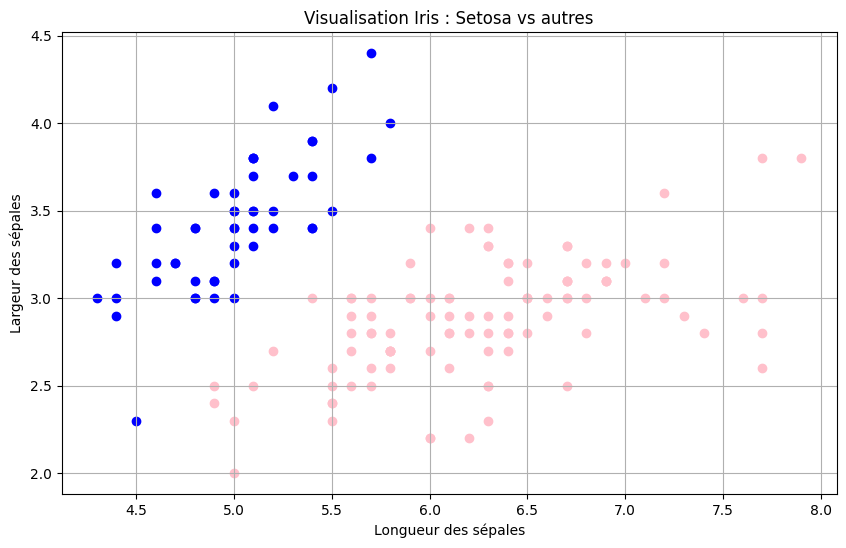

In [17]:
#Visualisation des données pyplot
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Classe 0 (Setosa)')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='pink', label='Classe 1 (Autres)')

#Etiquettes
plt.xlabel('Longueur des sépales')
plt.ylabel('Largeur des sépales')
plt.title('Visualisation Iris : Setosa vs autres')
plt.grid(True)
plt.show()

### Exercice 3 - Entrainement d’un modèle de régression logistique

In [16]:
#1. Import supplémentaire
from sklearn.linear_model import LogisticRegression

# 2. Création de l'objet LogisticRegression 
modele = LogisticRegression(C=1e20)

# 3. Entraînement avec la méthode fit()
modele.fit(X, y)

#Affichage
print("Coefficients :", modele.coef_)
print("Intercept :", modele.intercept_)

Coefficients : [[ 69.83261087 -79.81650518]]
Intercept : [-134.10250544]


### Exercice 4 - Prédire à quelle classe appartiennent de nouvelles fleurs d'iris

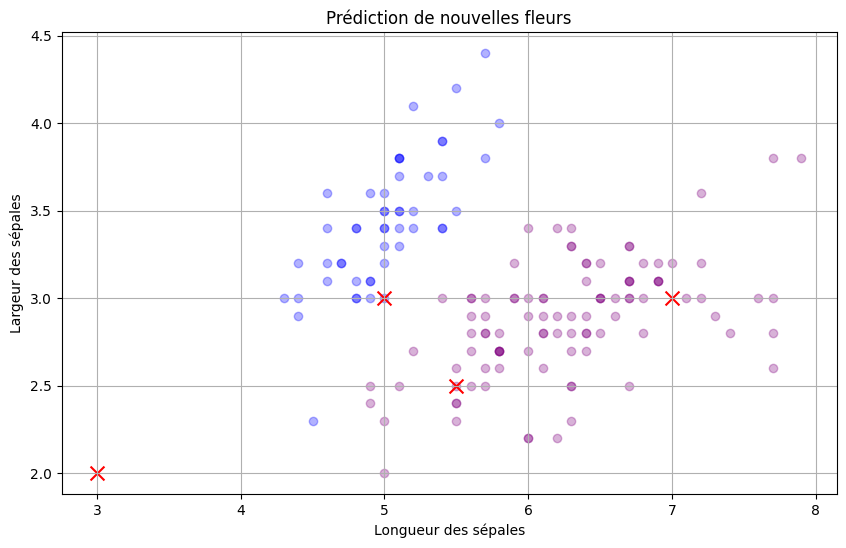

Résultats des prédictions :
Fleur [5.5, 2.5] Classe prédite : 1
Fleur [7, 3] Classe prédite : 1
Fleur [3, 2] Classe prédite : 0
Fleur [5, 3] Classe prédite : 0


In [24]:
# 1. Création des nouvelles observations
Iries_to_predict = [
    [5.5, 2.5],
    [7, 3],
    [3, 2],
    [5, 3]
]
X_new = np.array(Iries_to_predict)

# 2. Affichage graphique
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', alpha=0.3)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='purple', alpha=0.3)
plt.scatter(X_new[:, 0], X_new[:, 1], color='red', s=100, marker='x', label='A prédire')

plt.xlabel('Longueur des sépales')
plt.ylabel('Largeur des sépales')
plt.title('Prédiction de nouvelles fleurs')
plt.grid(True)
plt.show()

# 3. Prédiction des classes
predictions = modele.predict(X_new)

print("Résultats des prédictions :")
for i, point in enumerate(Iries_to_predict):
    print(f"Fleur {point} Classe prédite : {predictions[i]}")

### Exercice 5 - 

In [25]:
y_iter1 = iris.target.copy()
# Les fleurs 0 et 2 deviennent label 0 et les fleurs 1 restent 1
y_iter1[y_iter1 == 2] = 0 

# Entrainement
modele_1 = LogisticRegression(C=1e20)
modele_1.fit(X, y_iter1)

# Prédiction 
pred_1 = modele_1.predict(X_new)
print("Prédictions :", pred_1)

Prédictions : [1 0 1 0]


In [27]:
# Préparation des labels
y_iter2 = iris.target.copy()

# Les fleurs 0 et 1 deviennent 1, label 1 reste 1 et 2 reste 2
y_iter2[y_iter2 == 0] = 1 
# Problème : LogisticRegression veut du 0 et 1 (binaire).
# Transformer le label 2 en 0 
y_iter2[y_iter2 == 2] = 0

# Entrainement
modele_2 = LogisticRegression(C=1e20)
modele_2.fit(X, y_iter2)

# Prédiction
pred_2 = modele_2.predict(X_new)
print("Prédictions :", pred_2)

# Conclusion
print("En analysant les 3 résultats, on peut déduire l'espèce exacte de chaque point")

Prédictions : [1 0 1 1]
En analysant les 3 résultats, on peut déduire l'espèce exacte de chaque point
